In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import save_image
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import numpy as np
import torch
import cv2
from PIL import Image
from scipy.fftpack import dct
import os
from torch.utils.data import Dataset
from PIL import Image

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
class FrequencyPreprocessor:
    def __init__(
        self,
        image_size=256,
        low_freq_cutoff=16,
        normalize=False,
        mean=None,
        std=None
    ):
        self.image_size = image_size
        self.low_freq_cutoff = low_freq_cutoff
        self.normalize = normalize
        self.mean = mean
        self.std = std

        if self.normalize and (self.mean is None or self.std is None):
            raise ValueError("If normalize=True, you must provide mean and std.")

    def _to_numpy(self, img):
        if isinstance(img, Image.Image):
            img = np.array(img)
        elif not isinstance(img, np.ndarray):
            raise TypeError("Input must be a PIL image or NumPy array.")
        return img

    def _resize(self, img):
        return cv2.resize(img, (self.image_size, self.image_size))

    def _apply_dct(self, channel):
        """
        Apply 2D orthonormal DCT to one channel.
        Input channel expected in uint8 or similar image range.
        """
        channel = np.float32(channel) / 255.0

        # 2D DCT with orthonormal scaling
        dct_channel = dct(dct(channel.T, norm="ortho").T, norm="ortho")
        return dct_channel.astype(np.float32)

    def _high_pass_filter(self, dct_channel):
        """
        Remove the top-left low-frequency block and keep mid/high frequencies.
        """
        h, w = dct_channel.shape
        mask = np.ones((h, w), dtype=np.float32)
        mask[:self.low_freq_cutoff, :self.low_freq_cutoff] = 0.3
        return dct_channel * mask

    def _to_tensor(self, img):
        """
        Convert HWC NumPy array to CHW PyTorch tensor.
        """
        img = np.transpose(img, (2, 0, 1))
        return torch.from_numpy(img).float()

    def _normalize_tensor(self, tensor):
        """
        Standard normalization using dataset-level mean/std.
        mean and std can be scalars or length-3 lists/tuples.
        """
        mean = torch.tensor(self.mean, dtype=torch.float32).view(-1, 1, 1)
        std = torch.tensor(self.std, dtype=torch.float32).view(-1, 1, 1)
        return (tensor - mean) / std

    def __call__(self, img):
        img = self._to_numpy(img)
        img = self._resize(img)

        if len(img.shape) != 3 or img.shape[2] != 3:
            raise ValueError("Expected an RGB image with shape (H, W, 3).")

        processed_channels = []

        for c in range(3):
            channel = img[:, :, c]
            dct_channel = self._apply_dct(channel)
            filtered_channel = self._high_pass_filter(dct_channel)
            processed_channels.append(filtered_channel)

        processed_img = np.stack(processed_channels, axis=-1)  # HWC
        tensor = self._to_tensor(processed_img)

        if self.normalize:
            tensor = self._normalize_tensor(tensor)

        return tensor

In [ ]:
dataset_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/real_data"
generated_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/FA_GAN_Spoofed"
os.makedirs(generated_path, exist_ok=True)

class FaceDataset(Dataset):
    def __init__(self, folder_path, image_transform=None, freq_transform=None):
        self.folder_path = folder_path
        self.image_transform = image_transform
        self.freq_transform = freq_transform

        self.image_files = sorted([
            os.path.join(folder_path, img)
            for img in os.listdir(folder_path)
            if img.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert("RGB")

        if self.image_transform is not None:
            rgb_tensor = self.image_transform(image)
        else:
            rgb_tensor = image

        if self.freq_transform is not None:
            freq_tensor = self.freq_transform(image)
        else:
            freq_tensor = image

        return rgb_tensor, freq_tensor

In [ ]:
# create frequency preprocessor (THIS WAS MISSING)
rgb_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])
freq_transform = FrequencyPreprocessor(
    image_size=256,
    low_freq_cutoff=16,
    normalize=False
)

dataset = FaceDataset(
    folder_path=dataset_path,
    image_transform=rgb_transform,
    freq_transform=freq_transform
)

dataloader = DataLoader(
    dataset,
    batch_size=20,
    shuffle=False,
    num_workers=0
)

print("Dataset size:", len(dataset))
print("Number of batches:", len(dataloader))

Dataset size: 12000
Number of batches: 600


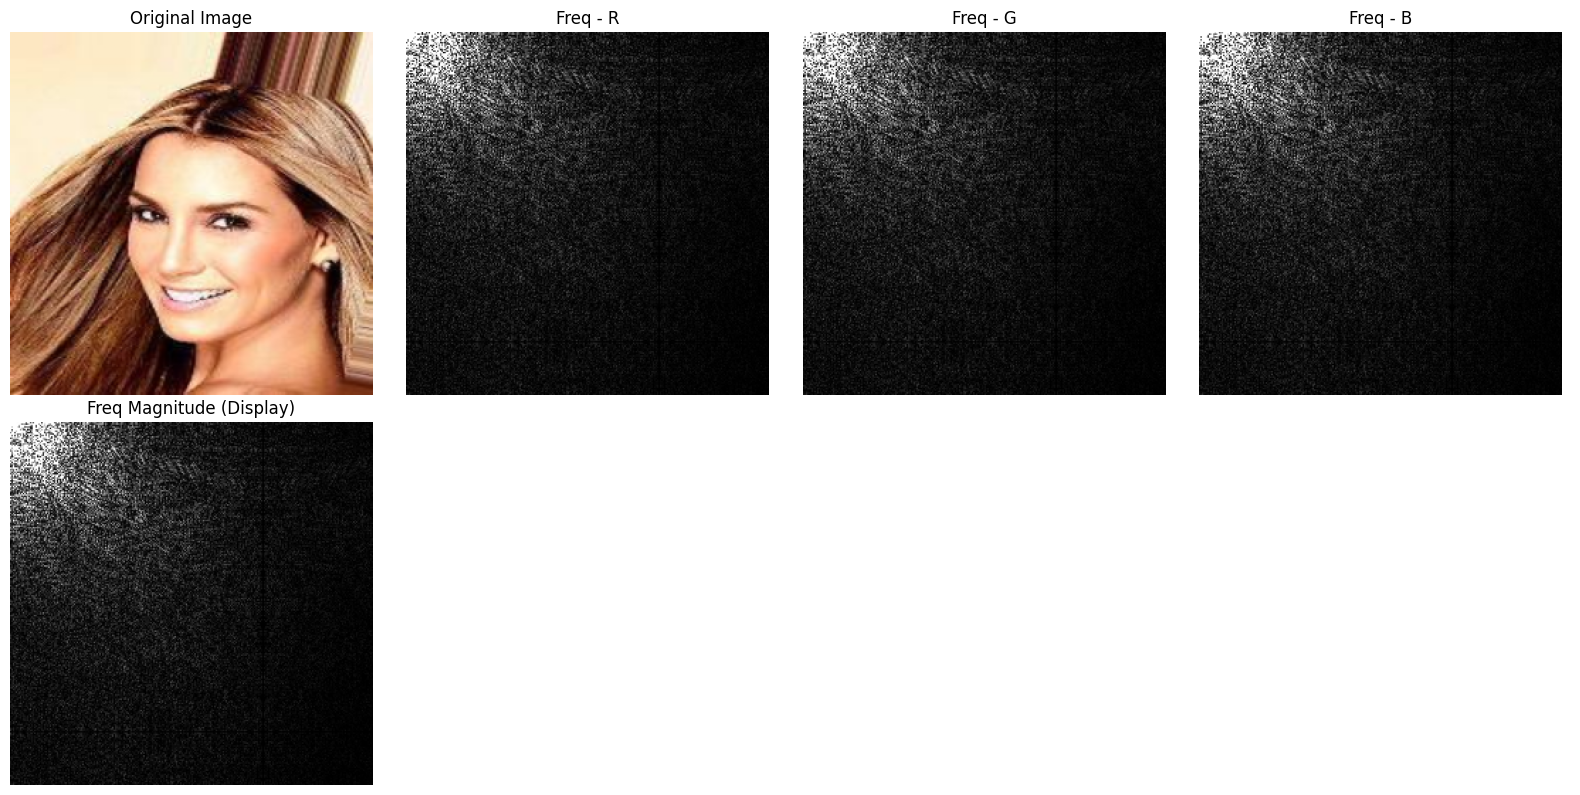

In [ ]:
# get one batch
for rgb, freq in dataloader:
    break

rgb_img = rgb[0].permute(1, 2, 0).cpu().numpy()
freq_img = freq[0].cpu().numpy()   # (C, H, W)

def freq_vis(channel):
    x = np.log1p(np.abs(channel))

    # robust contrast stretch for display only
    lo, hi = np.percentile(x, 1), np.percentile(x, 99)

    if hi - lo < 1e-8:
        return np.zeros_like(x)

    x = np.clip(x, lo, hi)
    x = (x - lo) / (hi - lo)
    return x

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes[0, 0].imshow(rgb_img)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

titles = ["Freq - R", "Freq - G", "Freq - B"]
for i in range(3):
    axes[0, i+1].imshow(freq_vis(freq_img[i]), cmap="gray")
    axes[0, i+1].set_title(titles[i])
    axes[0, i+1].axis("off")

freq_magnitude = np.mean(np.abs(freq_img), axis=0)
axes[1, 0].imshow(freq_vis(freq_magnitude), cmap="gray")
axes[1, 0].set_title("Freq Magnitude (Display)")
axes[1, 0].axis("off")

for j in range(1, 4):
    axes[1, j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
class AdvGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        # RGB branch (structure preservation)
        self.rgb_branch = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # 256 -> 128
            nn.ReLU(True),

            nn.Conv2d(32, 64, 4, 2, 1),  # 128 -> 64
            nn.BatchNorm2d(64),
            nn.ReLU(True)
        )

        # Frequency branch (guidance)
        self.freq_branch = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),   # 256 -> 128
            nn.ReLU(True),

            nn.Conv2d(64, 128, 4, 2, 1), # 128 -> 64
            nn.BatchNorm2d(128),
            nn.ReLU(True)
        )

        # Fusion encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(64 + 128, 256, 4, 2, 1),  # 64 -> 32
            nn.BatchNorm2d(256),
            nn.ReLU(True)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 32 -> 64
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 64 -> 128
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),     # 128 -> 256
            nn.Tanh()
        )

    def forward(self, rgb, freq):
        # Extract features
        rgb_feat = self.rgb_branch(rgb)
        freq_feat = self.freq_branch(freq)

        # Frequency dominance (no hyperparam exposure)
        freq_feat = 1.5 * freq_feat   # fixed internal bias

        # Fusion
        x = torch.cat([rgb_feat, freq_feat], dim=1)
        x = self.encoder(x)

        # Perturbation output
        delta = self.decoder(x)   # range [-1, 1]

        return delta

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(6, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 1),
        )

    def forward(self, rgb, freq):
        x = torch.cat([rgb, freq], dim=1)
        return self.model(x)

In [ ]:
G = AdvGenerator().to(device)
D = Discriminator().to(device)

In [ ]:
from torchvision.utils import save_image
import torch
import torch.nn.functional as F

# =========================================================
# DCT helpers
# =========================================================
def dct_1d_torch(x):
    N = x.shape[-1]
    v = torch.cat([x, x.flip(dims=[-1])], dim=-1)
    Vc = torch.fft.fft(v, dim=-1)

    k = torch.arange(N, device=x.device, dtype=x.dtype)
    factor = torch.exp(-1j * torch.pi * k / (2 * N))
    result = (Vc[..., :N] * factor).real

    result[..., 0] = result[..., 0] / torch.sqrt(
        torch.tensor(float(N), device=x.device, dtype=x.dtype)
    )

    if N > 1:
        result[..., 1:] = result[..., 1:] * torch.sqrt(
            torch.tensor(2.0 / N, device=x.device, dtype=x.dtype)
        )

    return result


def dct2_torch(x):
    x = dct_1d_torch(x)
    x = dct_1d_torch(x.transpose(-1, -2)).transpose(-1, -2)
    return x


# =========================================================
# DCT summed band energies (per-sample)
# =========================================================
def dct_band_energies_sum(img, low_ratio=0.10, mid_ratio=0.30):
    coeff = torch.abs(dct2_torch(img))

    _, _, H, W = coeff.shape
    low_cut = max(1, int(H * low_ratio))
    mid_cut = max(low_cut + 1, int(H * mid_ratio))

    low_region = coeff[:, :, :low_cut, :low_cut]
    low_energy = low_region.sum(dim=(-1, -2)).mean(dim=1)

    mid_mask = torch.zeros((H, W), device=img.device, dtype=torch.bool)
    mid_mask[:mid_cut, :mid_cut] = True
    mid_mask[:low_cut, :low_cut] = False

    mid_region = coeff[:, :, mid_mask]
    mid_energy = mid_region.sum(dim=-1).mean(dim=1)

    high_mask = torch.ones((H, W), device=img.device, dtype=torch.bool)
    high_mask[:mid_cut, :mid_cut] = False

    high_region = coeff[:, :, high_mask]
    high_energy = high_region.sum(dim=-1).mean(dim=1)

    return low_energy, mid_energy, high_energy


# =========================================================
# Directional frequency loss
# Goal:
#   MID  should increase
#   HIGH should increase
#   LOW  should not increase too much
# =========================================================
def directional_frequency_loss(
    real_img,
    fake_img,
    low_ratio=0.10,
    mid_ratio=0.30,
    target_mid_increase=5.0,
    target_high_increase=10.0,
    max_low_increase=5.0
):
    real_low, real_mid, real_high = dct_band_energies_sum(
        real_img, low_ratio, mid_ratio
    )
    fake_low, fake_mid, fake_high = dct_band_energies_sum(
        fake_img, low_ratio, mid_ratio
    )

    low_diff = fake_low - real_low
    mid_diff = fake_mid - real_mid
    high_diff = fake_high - real_high

    mid_loss = F.relu(target_mid_increase - mid_diff)
    high_loss = F.relu(target_high_increase - high_diff)
    low_loss = F.relu(low_diff - max_low_increase)

    total_loss = (mid_loss + high_loss + low_loss).mean()

    mid_pass = (mid_diff >= target_mid_increase).float()
    high_pass = (high_diff >= target_high_increase).float()
    low_pass = (low_diff <= max_low_increase).float()
    all_pass = mid_pass * high_pass * low_pass

    stats = {
        "low_diff": low_diff.mean().item(),
        "mid_diff": mid_diff.mean().item(),
        "high_diff": high_diff.mean().item(),
        "low_pass_rate": low_pass.mean().item(),
        "mid_pass_rate": mid_pass.mean().item(),
        "high_pass_rate": high_pass.mean().item(),
        "all_pass_rate": all_pass.mean().item()
    }

    return total_loss, stats


# =========================================================
# Hinge perturbation loss
# =========================================================
def hinge_perturbation_loss(delta, c=3.0):
    delta_flat = delta.view(delta.size(0), -1)
    delta_norm = torch.norm(delta_flat, p=2, dim=1)
    return torch.clamp(delta_norm - c, min=0.0).mean()


# =========================================================
# Border penalty
# =========================================================
def border_penalty(delta, border_width=24):
    _, _, H, W = delta.shape
    mask = torch.zeros((H, W), device=delta.device, dtype=delta.dtype)

    mask[:border_width, :] = 1.0
    mask[-border_width:, :] = 1.0
    mask[:, :border_width] = 1.0
    mask[:, -border_width:] = 1.0

    mask = mask.view(1, 1, H, W)
    return (delta.abs() * mask).mean()


# =========================================================
# Stride activity penalty
# =========================================================
def stride_activity_penalty(
    delta,
    patch_size=16,
    active_ratio=1.3,
    min_active_windows=4
):
    delta_mag = delta.abs().mean(dim=1, keepdim=True)
    patch_map = F.avg_pool2d(delta_mag, kernel_size=patch_size, stride=patch_size)

    patch_mean = patch_map.mean(dim=(-1, -2), keepdim=True)
    active_mask = (patch_map > (active_ratio * patch_mean)).float()

    active_count = active_mask.sum(dim=(-1, -2))
    penalty = F.relu(
        torch.tensor(float(min_active_windows), device=delta.device) - active_count
    ).mean()

    stats = {
        "active_windows": active_count.mean().item()
    }

    return penalty, stats


# =========================================================
# Screening evaluation
# =========================================================
def screen_trial(G_model, dataloader, device, epsilon=0.03, max_batches=10):
    G_model.eval()

    delta_vals = []
    low_vals = []
    mid_vals = []
    high_vals = []

    low_pass_vals = []
    mid_pass_vals = []
    high_pass_vals = []
    all_pass_vals = []

    active_vals = []

    with torch.no_grad():
        for b_idx, (rgb, freq) in enumerate(dataloader):
            if b_idx >= max_batches:
                break

            rgb = rgb.to(device)
            freq = freq.to(device)

            delta = G_model(rgb, freq)
            fake_img = torch.clamp(rgb + epsilon * delta, 0, 1)

            delta_vals.append(delta.abs().mean().item())

            _, freq_stats = directional_frequency_loss(rgb, fake_img)

            low_vals.append(freq_stats["low_diff"])
            mid_vals.append(freq_stats["mid_diff"])
            high_vals.append(freq_stats["high_diff"])

            low_pass_vals.append(freq_stats["low_pass_rate"])
            mid_pass_vals.append(freq_stats["mid_pass_rate"])
            high_pass_vals.append(freq_stats["high_pass_rate"])
            all_pass_vals.append(freq_stats["all_pass_rate"])

            _, stride_stats = stride_activity_penalty(
                delta,
                patch_size=16,
                active_ratio=1.3,
                min_active_windows=4
            )
            active_vals.append(stride_stats["active_windows"])

    return {
        "delta_mean": sum(delta_vals) / max(len(delta_vals), 1),
        "low_diff": sum(low_vals) / max(len(low_vals), 1),
        "mid_diff": sum(mid_vals) / max(len(mid_vals), 1),
        "high_diff": sum(high_vals) / max(len(high_vals), 1),
        "low_pass_rate": sum(low_pass_vals) / max(len(low_pass_vals), 1),
        "mid_pass_rate": sum(mid_pass_vals) / max(len(mid_pass_vals), 1),
        "high_pass_rate": sum(high_pass_vals) / max(len(high_pass_vals), 1),
        "all_pass_rate": sum(all_pass_vals) / max(len(all_pass_vals), 1),
        "active_windows": sum(active_vals) / max(len(active_vals), 1)
    }

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.utils import save_image
from tqdm.auto import tqdm
import os

# =========================================================
# HYPERPARAMETERS (EDIT HERE ONLY)
# =========================================================
eps = 0.15

lr_G = 1e-3
lr_D = 2e-3

betas_G = (0.5, 0.999)
betas_D = (0.5, 0.999)

lambda_gan = 2.0
lambda_freq = 0.04
lambda_cluster = 1.0
lambda_perturb = 0.0008
lambda_border = 1.0

perturb_bound = 3.0
epochs = 5

save_root = generated_path
os.makedirs(save_root, exist_ok=True)

# =========================================================
# REAL FILE ORDER
# =========================================================
real_files = sorted([
    f for f in os.listdir(dataset_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

# =========================================================
# DCT FUNCTIONS
# =========================================================
def dct_1d_torch(x):
    N = x.shape[-1]
    v = torch.cat([x, x.flip(dims=[-1])], dim=-1)
    Vc = torch.fft.fft(v, dim=-1)

    k = torch.arange(N, device=x.device, dtype=x.dtype)
    factor = torch.exp(-1j * torch.pi * k / (2 * N))
    result = (Vc[..., :N] * factor).real

    result[..., 0] /= torch.sqrt(torch.tensor(float(N), device=x.device, dtype=x.dtype))
    if N > 1:
        result[..., 1:] *= torch.sqrt(torch.tensor(2.0 / N, device=x.device, dtype=x.dtype))

    return result


def dct2_torch(x):
    x = dct_1d_torch(x)
    x = dct_1d_torch(x.transpose(-1, -2)).transpose(-1, -2)
    return x


def dct_band_energies_sum(img):
    coeff = torch.abs(dct2_torch(img))
    B, C, H, W = coeff.shape

    low_cut = int(H * 0.10)
    mid_cut = int(H * 0.30)

    low = coeff[:, :, :low_cut, :low_cut].sum((-1, -2)).mean(1)

    mid_mask = torch.zeros((H, W), device=img.device, dtype=torch.bool)
    mid_mask[:mid_cut, :mid_cut] = True
    mid_mask[:low_cut, :low_cut] = False
    mid = coeff[:, :, mid_mask].sum(-1).mean(1)

    high_mask = torch.ones((H, W), device=img.device, dtype=torch.bool)
    high_mask[:mid_cut, :mid_cut] = False
    high = coeff[:, :, high_mask].sum(-1).mean(1)

    return low, mid, high


# =========================================================
# DIRECTIONAL FREQUENCY LOSS
# =========================================================
def directional_frequency_loss(
    real,
    fake,
    target_mid_increase=5.0,
    target_high_increase=10.0,
    max_low_increase=5.0
):
    rl, rm, rh = dct_band_energies_sum(real)
    fl, fm, fh = dct_band_energies_sum(fake)

    low_diff = fl - rl
    mid_diff = fm - rm
    high_diff = fh - rh

    mid_loss = F.relu(target_mid_increase - mid_diff)
    high_loss = F.relu(target_high_increase - high_diff)
    low_loss = F.relu(low_diff - max_low_increase)

    loss = (mid_loss + high_loss + low_loss).mean()

    low_pass = (low_diff <= max_low_increase).float()
    mid_pass = (mid_diff >= target_mid_increase).float()
    high_pass = (high_diff >= target_high_increase).float()
    all_pass = low_pass * mid_pass * high_pass

    stats = {
        "low_diff": low_diff.mean().item(),
        "mid_diff": mid_diff.mean().item(),
        "high_diff": high_diff.mean().item(),
        "low_pass": low_pass.mean().item(),
        "mid_pass": mid_pass.mean().item(),
        "high_pass": high_pass.mean().item(),
        "all_pass": all_pass.mean().item()
    }

    return loss, stats


# =========================================================
# OTHER LOSSES
# =========================================================
def hinge_perturbation_loss(delta, c):
    return torch.clamp(
        delta.view(delta.size(0), -1).norm(p=2, dim=1) - c,
        min=0
    ).mean()


def border_penalty(delta):
    B, C, H, W = delta.shape
    mask = torch.zeros((H, W), device=delta.device)
    bw = 24

    mask[:bw, :] = 1
    mask[-bw:, :] = 1
    mask[:, :bw] = 1
    mask[:, -bw:] = 1

    mask = mask.view(1, 1, H, W)
    return (delta.abs() * mask).mean()


def stride_activity_penalty(delta):
    mag = delta.abs().mean(1, keepdim=True)
    patch = F.avg_pool2d(mag, 16, 16)

    patch_mean = patch.mean(dim=(-1, -2), keepdim=True)
    active_mask = (patch > 1.3 * patch_mean).float()
    active_count = active_mask.sum(dim=(-1, -2))

    penalty = F.relu(torch.tensor(4.0, device=delta.device) - active_count).mean()

    return penalty, {"active_windows": active_count.mean().item()}


def patch_dominance_stats(delta):
    mag = delta.abs().mean(1, keepdim=True)
    patch = F.avg_pool2d(mag, 16, 16)
    vals = patch.view(patch.size(0), -1)

    return {
        "dominance_ratio": (
            vals.max(1).values / (vals.sum(1) + 1e-8)
        ).mean().item()
    }


# =========================================================
# INIT
# =========================================================
G = AdvGenerator().to(device)
D = Discriminator().to(device)

criterion = nn.BCEWithLogitsLoss()

opt_G = torch.optim.Adam(G.parameters(), lr=lr_G, betas=betas_G)
opt_D = torch.optim.Adam(D.parameters(), lr=lr_D, betas=betas_D)

# =========================================================
# TRAIN LOOP
# =========================================================
for epoch in range(epochs):

    G.train()
    D.train()

    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")

    for rgb, freq in pbar:

        rgb = rgb.to(device)
        freq = freq.to(device)

        bs = rgb.size(0)
        real = torch.ones(bs, 1, device=device)
        fake = torch.zeros(bs, 1, device=device)

        # ================= D =================
        for _ in range(3):
            delta = G(rgb, freq)
            fake_img = torch.clamp(rgb + eps * delta, 0, 1)

            lossD = (
                criterion(D(rgb, freq), real) +
                criterion(D(fake_img.detach(), freq), fake)
            )

            opt_D.zero_grad()
            lossD.backward()
            opt_D.step()

        # ================= G =================
        delta = G(rgb, freq)
        fake_img = torch.clamp(rgb + eps * delta, 0, 1)

        loss_gan = criterion(D(fake_img, freq), real)

        freq_loss, stats = directional_frequency_loss(rgb, fake_img)

        cluster_loss, cluster_stats = stride_activity_penalty(delta)
        hinge_loss = hinge_perturbation_loss(delta, perturb_bound)
        b_loss = border_penalty(delta)

        lossG = (
            lambda_gan * loss_gan +
            lambda_freq * freq_loss +
            lambda_cluster * cluster_loss +
            lambda_perturb * hinge_loss +
            lambda_border * b_loss
        )

        opt_G.zero_grad()
        lossG.backward()
        opt_G.step()

        dom = patch_dominance_stats(delta)

        pbar.set_postfix({
            "GAN": f"{loss_gan.item():.3f}",
            "Freq": f"{freq_loss.item():.3f}",
            "Low": f"{stats['low_diff']:.1f}",
            "Mid": f"{stats['mid_diff']:.1f}",
            "High": f"{stats['high_diff']:.1f}",
            "MidP": f"{stats['mid_pass']:.2f}",
            "HighP": f"{stats['high_pass']:.2f}",
            "AllP": f"{stats['all_pass']:.2f}",
            "Cluster": f"{cluster_loss.item():.3f}",
            "Hinge": f"{hinge_loss.item():.3f}",
            "Dom": f"{dom['dominance_ratio']:.3f}",
            "Δ": f"{delta.abs().mean().item():.4f}"
        })

    # ================= SAVE =================
    save_dir = os.path.join(save_root, f"epoch_{epoch+1:02d}")
    os.makedirs(save_dir, exist_ok=True)

    G.eval()
    idx = 0

    with torch.no_grad():
        for rgb, freq in dataloader:
            rgb = rgb.to(device)
            freq = freq.to(device)

            delta = G(rgb, freq)
            fake_img = torch.clamp(rgb + eps * delta, 0, 1)

            for i in range(fake_img.size(0)):
                if idx >= len(real_files):
                    break

                name = os.path.splitext(real_files[idx])[0]
                save_image(fake_img[i], os.path.join(save_dir, f"{name}_fake.png"))
                idx += 1

    print(f"✅ Saved epoch {epoch+1}")

Epoch 1/5:   0%|          | 0/600 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.fftpack import dct
from scipy.ndimage import gaussian_filter
from tqdm import tqdm

# =========================================================
# CONFIG
# =========================================================
real_folder = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/real_data"                  # folder-level real
fake_folder = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/FA_GAN_Spoofed/_1"         # folder-level fake


IMG_SIZE = 256

LOW_RATIO = 0.10
MID_RATIO = 0.30
HEATMAP_SIGMA = 6

# =========================================================
# HELPERS
# =========================================================
def load_img(path, size=256):
    img = Image.open(path).convert("RGB")
    img = img.resize((size, size))
    return np.array(img).astype(np.float32) / 255.0

def dct2(channel):
    return dct(dct(channel.T, norm="ortho").T, norm="ortho")

def compute_dct_band_energy(img, low_ratio=0.10, mid_ratio=0.30):
    energies = {"low": 0.0, "mid": 0.0, "high": 0.0}

    for c in range(3):
        coeff = dct2(img[:, :, c])
        coeff = np.abs(coeff)

        h, w = coeff.shape
        low_cut = max(1, int(h * low_ratio))
        mid_cut = max(low_cut + 1, int(h * mid_ratio))

        # LOW
        low = coeff[:low_cut, :low_cut].sum()

        # MID
        mid_mask = np.zeros_like(coeff, dtype=bool)
        mid_mask[:mid_cut, :mid_cut] = True
        mid_mask[:low_cut, :low_cut] = False
        mid = coeff[mid_mask].sum()

        # HIGH
        high_mask = np.ones_like(coeff, dtype=bool)
        high_mask[:mid_cut, :mid_cut] = False
        high = coeff[high_mask].sum()

        energies["low"] += low
        energies["mid"] += mid
        energies["high"] += high

    return energies

def get_sorted_image_files(folder):
    return sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

def process_folder(folder, low_ratio=0.10, mid_ratio=0.30):
    files = get_sorted_image_files(folder)

    total = {"low": 0.0, "mid": 0.0, "high": 0.0}
    count = 0

    for fname in tqdm(files, desc=f"Processing {folder}"):
        path = os.path.join(folder, fname)

        try:
            img = load_img(path, IMG_SIZE)
            energy = compute_dct_band_energy(img, low_ratio, mid_ratio)

            for k in total:
                total[k] += energy[k]
            count += 1

        except Exception as e:
            print(f"Skipping {fname}: {e}")

    if count == 0:
        raise ValueError(f"No valid images found in {folder}")

    avg = {k: total[k] / count for k in total}
    return avg

def dct_rgb(img):
    out = []
    for c in range(3):
        out.append(dct2(img[:, :, c]))
    return np.stack(out, axis=-1)

# =========================================================
# 1) FOLDER-LEVEL REPORT
# =========================================================
real_avg = process_folder(real_folder, LOW_RATIO, MID_RATIO)
fake_avg = process_folder(fake_folder, LOW_RATIO, MID_RATIO)

diff_avg = {k: fake_avg[k] - real_avg[k] for k in real_avg}

print("\n" + "="*60)
print("FOLDER-LEVEL FREQUENCY REPORT")
print("="*60)

print("\nReal folder average:")
for k, v in real_avg.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nFake folder average:")
for k, v in fake_avg.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nDifference (Fake - Real):")
for k, v in diff_avg.items():
    print(f"{k.upper():>5}: {v:.4f}")
# =========================================================
# 2) PAIRWISE COMPARISON REPORT
# =========================================================

real_files = get_sorted_image_files(real_folder)
fake_files = get_sorted_image_files(fake_folder)

assert len(real_files) == len(fake_files), "Mismatch in real and fake image counts!"

mid_high_count = 0
high_only_count = 0

total_pairs = len(real_files)

for r_name, f_name in tqdm(zip(real_files, fake_files), total=total_pairs, desc="Pairwise Comparison"):

    real_path = os.path.join(real_folder, r_name)
    fake_path = os.path.join(fake_folder, f_name)

    try:
        real_img = load_img(real_path, IMG_SIZE)
        fake_img = load_img(fake_path, IMG_SIZE)

        real_energy = compute_dct_band_energy(real_img, LOW_RATIO, MID_RATIO)
        fake_energy = compute_dct_band_energy(fake_img, LOW_RATIO, MID_RATIO)

        # CONDITION 1: MID + HIGH both higher
        if (fake_energy["mid"] > real_energy["mid"]) and (fake_energy["high"] > real_energy["high"]):
            mid_high_count += 1

        # CONDITION 2: ONLY HIGH higher
        if fake_energy["high"] > real_energy["high"]:
            high_only_count += 1

    except Exception as e:
        print(f"Skipping pair {r_name}, {f_name}: {e}")

print("\n" + "="*60)
print("PAIRWISE FREQUENCY COMPARISON")
print("="*60)

print(f"Total Pairs: {total_pairs}")
print(f"Fake > Real in MID + HIGH: {mid_high_count}")
print(f"Fake > Real in HIGH only: {high_only_count}")

print("\nPercentages:")
print(f"MID + HIGH: {(mid_high_count / total_pairs) * 100:.2f}%")
print(f"HIGH only : {(high_only_count / total_pairs) * 100:.2f}%")

Processing /content/drive/MyDrive/Colab Notebooks/thesis dataset/train/real_data: 100%|██████████| 12000/12000 [09:22<00:00, 21.35it/s]
Processing /content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/FA_GAN_Spoofed/_1: 100%|██████████| 12000/12000 [08:18<00:00, 24.09it/s]



FOLDER-LEVEL FREQUENCY REPORT

Real folder average:
  LOW: 2427.1672
  MID: 2059.9121
 HIGH: 2453.4546

Fake folder average:
  LOW: 2389.2976
  MID: 1967.5316
 HIGH: 2616.5247

Difference (Fake - Real):
  LOW: -37.8696
  MID: -92.3805
 HIGH: 163.0701


Pairwise Comparison: 100%|██████████| 12000/12000 [06:06<00:00, 32.71it/s]


PAIRWISE FREQUENCY COMPARISON
Total Pairs: 12000
Fake > Real in MID + HIGH: 31
Fake > Real in HIGH only: 8728

Percentages:
MID + HIGH: 0.26%
HIGH only : 72.73%



SINGLE-IMAGE FREQUENCY REPORT

Real image energy:
  LOW: 1987.3723
  MID: 1662.1316
 HIGH: 1524.0035

Fake image energy:
  LOW: 1953.4814
  MID: 1596.3489
 HIGH: 1815.3403

Difference (Fake - Real):
  LOW: -33.8909
  MID: -65.7827
 HIGH: 291.3368


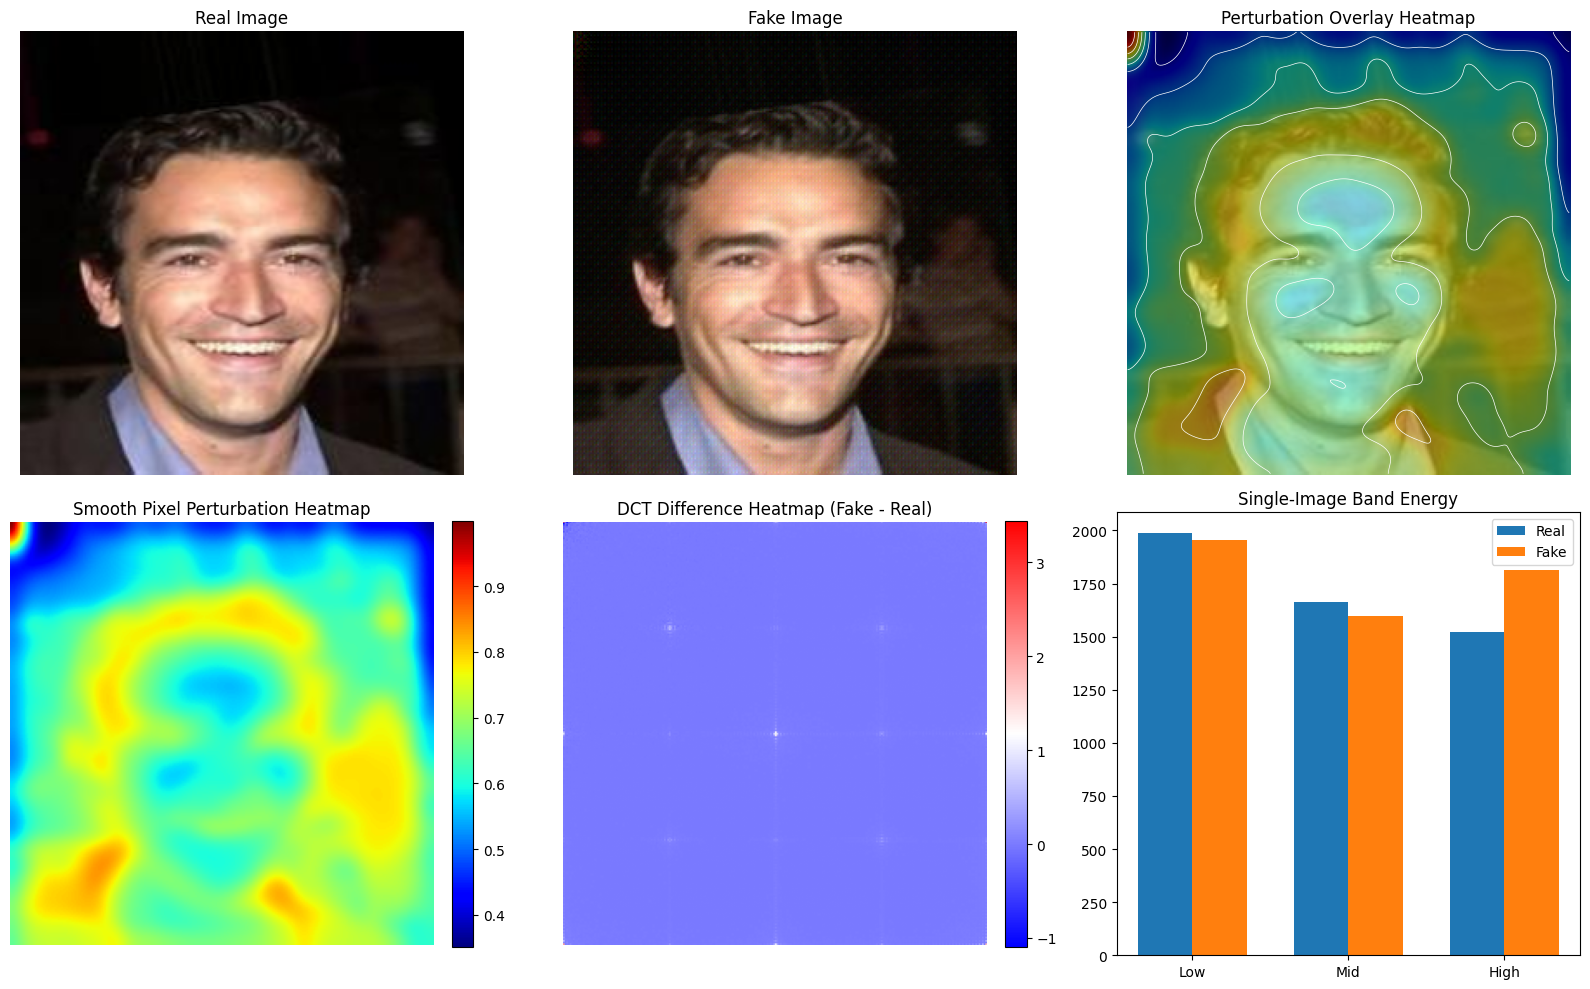


Single real path : /content/drive/MyDrive/Colab Notebooks/thesis dataset/train/real_data/000050.jpg
Single fake path : /content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/FA_GAN_Spoofed/_1/000050_fake.png


In [8]:
# MANUAL single-image paths
single_real_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/real_data/000050.jpg"          # change this
single_fake_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/FA_GAN_Spoofed/_1/000050_fake.png"  # change this

# =========================================================
# 2) SINGLE-IMAGE REPORT (MANUAL PATH INPUT)
# =========================================================
real_img = load_img(single_real_path, IMG_SIZE)
fake_img = load_img(single_fake_path, IMG_SIZE)

real_energy = compute_dct_band_energy(real_img, LOW_RATIO, MID_RATIO)
fake_energy = compute_dct_band_energy(fake_img, LOW_RATIO, MID_RATIO)
single_diff = {k: fake_energy[k] - real_energy[k] for k in real_energy}

print("\n" + "="*60)
print("SINGLE-IMAGE FREQUENCY REPORT")
print("="*60)

print("\nReal image energy:")
for k, v in real_energy.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nFake image energy:")
for k, v in fake_energy.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nDifference (Fake - Real):")
for k, v in single_diff.items():
    print(f"{k.upper():>5}: {v:.4f}")

# =========================================================
# 3) HEATMAPS FOR THE SAME SINGLE IMAGE
# =========================================================
delta = np.abs(fake_img - real_img)
delta_gray = delta.mean(axis=2)
smooth_map = gaussian_filter(delta_gray, sigma=HEATMAP_SIGMA)
smooth_map = smooth_map / (smooth_map.max() + 1e-8)

real_dct = dct_rgb(real_img)
fake_dct = dct_rgb(fake_img)

real_dct_mag = np.abs(real_dct).mean(axis=2)
fake_dct_mag = np.abs(fake_dct).mean(axis=2)
dct_diff = fake_dct_mag - real_dct_mag

# =========================================================
# 4) PLOTS
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(real_img)
axes[0, 0].set_title("Real Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(fake_img)
axes[0, 1].set_title("Fake Image")
axes[0, 1].axis("off")

axes[0, 2].imshow(real_img)
axes[0, 2].imshow(smooth_map, cmap="jet", alpha=0.5)
axes[0, 2].contour(smooth_map, colors="white", linewidths=0.5)
axes[0, 2].set_title("Perturbation Overlay Heatmap")
axes[0, 2].axis("off")

im1 = axes[1, 0].imshow(smooth_map, cmap="jet")
axes[1, 0].set_title("Smooth Pixel Perturbation Heatmap")
axes[1, 0].axis("off")
plt.colorbar(im1, ax=axes[1, 0], fraction=0.046, pad=0.04)

im2 = axes[1, 1].imshow(dct_diff, cmap="bwr")
axes[1, 1].set_title("DCT Difference Heatmap (Fake - Real)")
axes[1, 1].axis("off")
plt.colorbar(im2, ax=axes[1, 1], fraction=0.046, pad=0.04)

bands = ["Low", "Mid", "High"]
real_vals = [real_energy["low"], real_energy["mid"], real_energy["high"]]
fake_vals = [fake_energy["low"], fake_energy["mid"], fake_energy["high"]]

x = np.arange(len(bands))
width = 0.35

axes[1, 2].bar(x - width/2, real_vals, width, label="Real")
axes[1, 2].bar(x + width/2, fake_vals, width, label="Fake")
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(bands)
axes[1, 2].set_title("Single-Image Band Energy")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print("\nSingle real path :", single_real_path)
print("Single fake path :", single_fake_path)

In [11]:
# =========================================================
# DATASET CONSTRUCTION (MID+HIGH + HIGH ONLY)
# =========================================================

import shutil
import random
from tqdm import tqdm

save_final_folder = "/content/drive/MyDrive/Colab Notebooks/FA_GAN_SPOOFED_FINAL"
os.makedirs(save_final_folder, exist_ok=True)

mid_high_files = []
high_only_files = []

print("\nFiltering valid samples...")

for r_name, f_name in tqdm(zip(real_files, fake_files), total=len(real_files)):

    real_path = os.path.join(real_folder, r_name)
    fake_path = os.path.join(fake_folder, f_name)

    try:
        real_img = load_img(real_path, IMG_SIZE)
        fake_img = load_img(fake_path, IMG_SIZE)

        real_energy = compute_dct_band_energy(real_img, LOW_RATIO, MID_RATIO)
        fake_energy = compute_dct_band_energy(fake_img, LOW_RATIO, MID_RATIO)

        mid_diff = fake_energy["mid"] - real_energy["mid"]
        high_diff = fake_energy["high"] - real_energy["high"]

        # MID + HIGH
        if (mid_diff > 0) and (high_diff > 0):
            mid_high_files.append(f_name)

        # HIGH ONLY
        elif (high_diff > 0):
            high_only_files.append(f_name)

    except Exception as e:
        print(f"Skipping {f_name}: {e}")

print("\nCounts:")
print(f"MID + HIGH : {len(mid_high_files)}")
print(f"HIGH ONLY  : {len(high_only_files)}")

# =========================================================
# SELECTION
# =========================================================

TOTAL_TARGET = 6000

selected_mid_high = mid_high_files
remaining_needed = TOTAL_TARGET - len(selected_mid_high)

if remaining_needed <= 0:
    selected_files = random.sample(selected_mid_high, TOTAL_TARGET)
else:
    if remaining_needed > len(high_only_files):
        raise ValueError("Not enough HIGH-only samples!")

    selected_high_only = random.sample(high_only_files, remaining_needed)
    selected_files = selected_mid_high + selected_high_only

print("\nFinal Selection:")
print(f"MID + HIGH : {len(selected_mid_high)}")
print(f"HIGH ONLY  : {len(selected_files) - len(selected_mid_high)}")
print(f"TOTAL      : {len(selected_files)}")

# =========================================================
# COPY FILES
# =========================================================

print("\nSaving dataset...")

for fname in tqdm(selected_files, desc="Copying Files"):
    src = os.path.join(fake_folder, fname)
    dst = os.path.join(save_final_folder, fname)

    try:
        shutil.copy(src, dst)
    except Exception as e:
        print(f"Error copying {fname}: {e}")

print("\nDataset creation complete ✅")


Filtering valid samples...


100%|██████████| 12000/12000 [04:19<00:00, 46.24it/s]



Counts:
MID + HIGH : 31
HIGH ONLY  : 8697

Final Selection:
MID + HIGH : 31
HIGH ONLY  : 5969
TOTAL      : 6000

Saving dataset...


Copying Files: 100%|██████████| 6000/6000 [02:03<00:00, 48.77it/s]


Dataset creation complete ✅
